# Tuần 07 — Thực hành k-Means: 3 bài

Demo `03_Demo-kMeans.ipynb` gom cụm bằng tay trên dữ liệu giả 2 chiều.

File này có **3 bài**. Mỗi bài là một bộ dữ liệu thật trên Kaggle. Cả 3 bài đều làm. Dùng `sklearn.cluster.KMeans`.

Clustering không chia train/test và không có nhãn để học. `StandardScaler` fit trên toàn bộ bảng feature. Không đưa cột ID hay tên vào khoảng cách.

Tải 3 file vào `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |

Ba bộ này cũng được dùng ở `09_TH-DBSCAN.ipynb`, để so sánh hai cách gom cụm trên cùng dữ liệu.


In [31]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


## Phần chung

Elbow: với mỗi `K` từ 1 đến `k_max`, fit `KMeans` (`n_init=10`, `random_state=3000`), lưu `inertia_`, rồi vẽ. Chỗ khuỷu tay là `K` nên thử.

Sau khi có nhãn, bảng trung bình theo cụm giúp đọc ý nghĩa từng nhóm.


In [32]:
def ve_elbow(X_scaled, k_max=10):
    ks = list(range(1, k_max + 1))
    inertias = []
    for k in ks:
        # TODO: fit KMeans với n_clusters=k, n_init=10, random_state=3000
        # lưu model.inertia_ vào inertias
        model = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=3000
        )
        model.fit(X_scaled)
        inertias.append(model.inertia_)
    
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.xlabel('K')
    plt.ylabel('inertia')
    plt.grid(True)
    plt.show()
    return ks, inertias


def bang_trung_binh(df_goc, labels, cot_so):
    tam = df_goc[cot_so].copy()
    tam['cum'] = labels
    return tam.groupby('cum').mean().round(2)


---

# Bài 1 — Khách hàng trung tâm thương mại

Nguồn: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

200 khách. Cột: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

Bài này chỉ dùng **thu nhập** và **điểm chi tiêu**. Bỏ `CustomerID`. Không đưa `Gender` vào khoảng cách. Có thể để `Age` sang một lần chạy riêng nếu còn thời gian.

Chuẩn hóa hai cột, vẽ elbow, chọn `K`, tô màu scatter theo cụm. Dấu `x` là tâm cụm tính trên **số gốc** (trung bình thu nhập và điểm chi tiêu của các điểm trong cụm), để đọc được đơn vị thật.


In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mythi\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


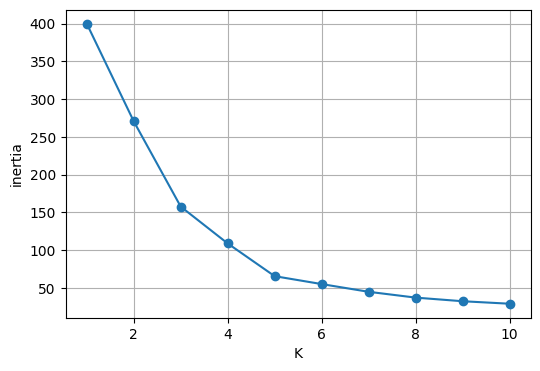

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [399.99999999999994,
  270.6682049684468,
  157.70400815035947,
  108.92131661364357,
  65.56840815571681,
  55.10377812115057,
  44.86628627232253,
  37.18175782682131,
  32.37724377444034,
  29.07617685124427])

In [34]:
mall = pd.read_csv('data/Mall_Customers.csv')
print(mall.head())
print(mall.shape)

cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)


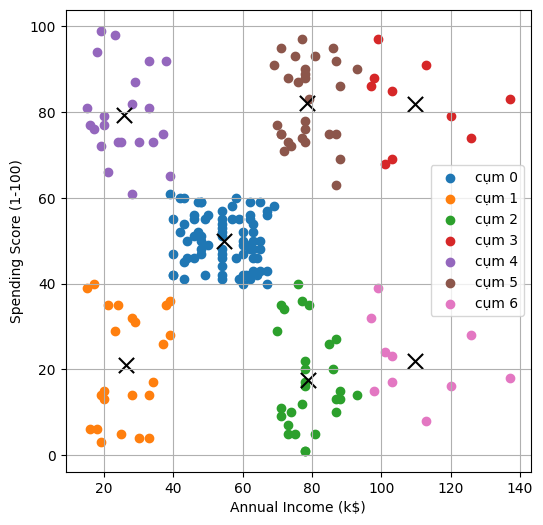

     Annual Income (k$)  Spending Score (1-100)
cum                                            
0                 54.62                   50.03
1                 26.30                   20.91
2                 78.89                   17.43
3                109.70                   82.00
4                 25.73                   79.36
5                 78.55                   82.17
6                109.70                   22.00
số điểm mỗi cụm: (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([78, 23, 28, 10, 22, 29, 10]))


In [35]:
# TODO: chọn K từ elbow
K = 7
model = KMeans(n_clusters=K, n_init=10, random_state=3000)
labels = model.fit_predict(X_scaled)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
    plt.scatter(pts[:, 0].mean(), pts[:, 1].mean(), c='black', marker='x', s=120)
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

print(bang_trung_binh(mall, labels, cot))
print('số điểm mỗi cụm:', np.unique(labels, return_counts=True))


**Nộp kèm bài 1**

1. `K` bạn chọn là bao nhiêu? Elbow gãy ở đâu?
2. Mô tả từng cụm bằng thu nhập và điểm chi tiêu (cao / thấp). Cụm nào đáng ưu tiên cho khuyến mãi?
3. Nếu thêm cột `Age` vào `X` rồi chuẩn hóa lại, bạn có đổi `K` không?


In [36]:
# Bài 1

# 1.
"""K = 7. Elbow thường gãy khoảng K = 7."""

# 2.
"""Có thể chia khách hàng thành các nhóm có thu nhập và mức chi tiêu
thấp/cao khác nhau. Cụm có thu nhập cao và điểm chi tiêu cao là nhóm
nên ưu tiên cho các chương trình khuyến mãi vì có khả năng mua sắm cao."""

# 3.
"""Nếu thêm Age và chuẩn hóa lại, K có thể giữ nguyên nếu elbow vẫn nằm
quanh K = 7. Tuy nhiên vị trí các điểm và cách phân nhóm có thể thay đổi
vì Age trở thành một đặc trưng trong khoảng cách."""

'Nếu thêm Age và chuẩn hóa lại, K có thể giữ nguyên nếu elbow vẫn nằm\nquanh K = 7. Tuy nhiên vị trí các điểm và cách phân nhóm có thể thay đổi\nvì Age trở thành một đặc trưng trong khoảng cách.'

---

# Bài 2 — Phân nhóm quốc gia

Nguồn: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

167 nước, file `Country-data.csv`. Cột `country` là tên, không đưa vào `X`.

Các cột số: `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`.

`income` và `gdpp` lớn hơn `child_mort` rất nhiều. Bắt buộc `StandardScaler`. Chọn `K` bằng elbow (thường thử quanh 3). In trung bình `child_mort`, `income`, `life_expec`, `gdpp` theo cụm, và liệt kê khoảng 8 tên nước mỗi cụm.


In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mythi\.cache\kagglehub\datasets\rohan0301\unsupervised-learning-on-country-data\versions\2


               country  child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
0          Afghanistan        90.2     10.0    7.58     44.9    1610       9.44        56.2       5.82    553
1              Albania        16.6     28.0    6.55     48.6    9930       4.49        76.3       1.65   4090
2              Algeria        27.3     38.4    4.17     31.4   12900      16.10        76.5       2.89   4460
3               Angola       119.0     62.3    2.85     42.9    5900      22.40        60.1       6.16   3530
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100       1.44        76.8       2.13  12200
(167, 10)


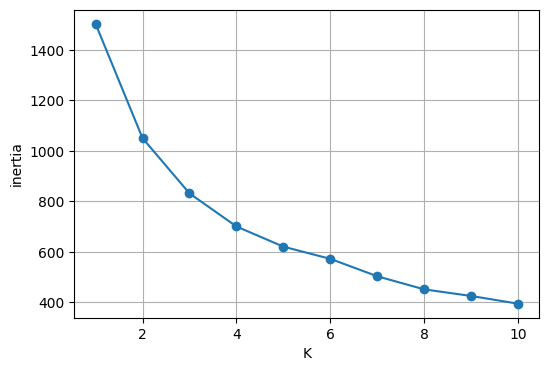

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [1503.0000000000002,
  1050.2145582853304,
  831.4244352086873,
  700.3917199643636,
  620.4488115302204,
  572.0890405033384,
  503.0948550735083,
  451.32364852916595,
  425.20634399408493,
  394.56762525044974])

In [38]:
country = pd.read_csv('data/Country-data.csv')

print(country.head())
print(country.shape)

cot_so = [c for c in country.columns if c != 'country']
# TODO: X từ cot_so, chuẩn hóa
X = country[cot_so].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)


In [39]:
K = 2
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(country, labels, ['child_mort', 'income', 'life_expec', 'gdpp']))

for cum in np.unique(labels):
    ten = country.loc[labels == cum, 'country'].head(8).tolist()
    print(cum, ten)


     child_mort    income  life_expec      gdpp
cum                                            
0         12.16  26017.17       76.49  20507.98
1         76.28   4227.40       61.91   1981.24
0 ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan']
1 ['Afghanistan', 'Angola', 'Bangladesh', 'Benin', 'Bolivia', 'Botswana', 'Burkina Faso', 'Burundi']


**Nộp kèm bài 2**

1. `K` bạn chọn? Cụm nào có `child_mort` cao và `gdpp` thấp?
2. Kể tên 3 nước thuộc cụm đó và 3 nước thuộc cụm có `gdpp` cao.
3. Vì sao không chuẩn hóa thì `income` và `gdpp` sẽ át các cột còn lại?


In [40]:
# Bài 2


# 1. K
print("\n1. K được chọn:", K)

# Bảng trung bình
bang_tb = bang_trung_binh(
    country,
    labels,
    ['child_mort', 'income', 'life_expec', 'gdpp']
)

print("\nBảng trung bình:")
print(bang_tb)

# Tìm cụm
cum_ngheo = bang_tb['gdpp'].idxmin()
cum_giau = bang_tb['gdpp'].idxmax()

print("\nCụm có child_mort cao và gdpp thấp:", cum_ngheo)

# 2. Lấy 3 nước
nuoc_ngheo = country.loc[
    labels == cum_ngheo,
    'country'
].head(3).tolist()

nuoc_giau = country.loc[
    labels == cum_giau,
    'country'
].head(3).tolist()

print("\n2. Ba nước thuộc cụm child_mort cao, gdpp thấp:")
print(nuoc_ngheo)

print("\nBa nước thuộc cụm gdpp cao:")
print(nuoc_giau)

# 3. Giải thích
print("""
3. Nếu không chuẩn hóa, income và gdpp sẽ át các cột còn lại vì
hai biến này có giá trị lớn hơn nhiều. K-Means sử dụng khoảng cách
Euclid nên các biến có độ lớn lớn sẽ đóng góp nhiều hơn vào khoảng
cách, làm kết quả phân cụm bị chi phối bởi income và gdpp.
""")



1. K được chọn: 2

Bảng trung bình:
     child_mort    income  life_expec      gdpp
cum                                            
0         12.16  26017.17       76.49  20507.98
1         76.28   4227.40       61.91   1981.24

Cụm có child_mort cao và gdpp thấp: 1

2. Ba nước thuộc cụm child_mort cao, gdpp thấp:
['Afghanistan', 'Angola', 'Bangladesh']

Ba nước thuộc cụm gdpp cao:
['Albania', 'Algeria', 'Antigua and Barbuda']

3. Nếu không chuẩn hóa, income và gdpp sẽ át các cột còn lại vì
hai biến này có giá trị lớn hơn nhiều. K-Means sử dụng khoảng cách
Euclid nên các biến có độ lớn lớn sẽ đóng góp nhiều hơn vào khoảng
cách, làm kết quả phân cụm bị chi phối bởi income và gdpp.



---

# Bài 3 — Khách sỉ

Nguồn: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

440 khách hàng bán sỉ. File `Wholesale customers data.csv`.

Cột: `Channel`, `Region`, `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

`Channel` (1 = Horeca, 2 = Retail) và `Region` là mã nhóm, không phải số tiền. **Không** đưa hai cột này vào `X`. Gom cụm trên 6 cột chi tiêu, sau chuẩn hóa. Rồi dùng `pd.crosstab` để xem mỗi cụm nằm ở kênh nào.


In [41]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("binovi/wholesale-customers-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mythi\.cache\kagglehub\datasets\binovi\wholesale-customers-data-set\versions\1


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
(440, 8)


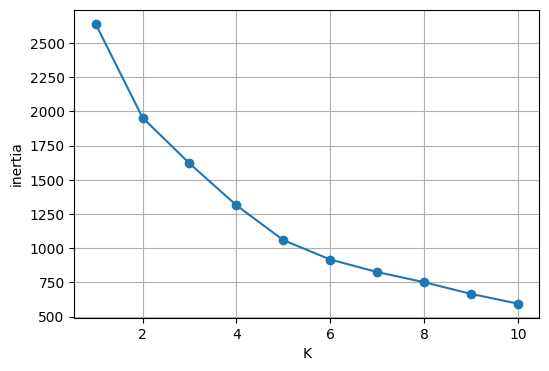

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [2640.0,
  1954.1835647259281,
  1619.952782172456,
  1313.7580090341148,
  1058.7712532570085,
  917.4454350272306,
  825.8359775416383,
  751.7362093470331,
  666.2237996202155,
  594.8556455931528])

In [42]:

ws = pd.read_csv('data/Wholesale customers data.csv')

print(ws.head())
print(ws.shape)

cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
# TODO: chuẩn hóa 6 cột chi tiêu
X = ws[cot_chi].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)


In [43]:
K = 4
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(ws, labels, cot_chi))
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))


        Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
cum                                                                      
0    13599.16   3050.81   3857.97   3281.05            854.62     1168.96
1    15964.90  34708.50  48536.90   3054.60          24875.20     2942.80
2     5778.66  10350.05  15694.88   1532.84           6689.96     1892.10
3    60571.67  30120.33  17314.67  38049.33           2153.00    20700.67
Channel    1   2
cum             
0        278  38
1          0  10
2         17  94
3          3   0


**Nộp kèm bài 3**

1. `K` bạn chọn? Cụm nào chi mạnh cho `Grocery` và `Detergents_Paper`?
2. Cụm đó lệch về `Channel` nào trên bảng crosstab?
3. So với bài 1: vì sao bài 3 không vẽ một scatter là đủ để đọc cụm?


In [44]:
# Bài 3


# 1. K đã chọn
print("1. K được chọn:", K)

# Bảng trung bình của từng cụm
bang_tb = bang_trung_binh(ws, labels, cot_chi)

print("\nBảng trung bình:")
print(bang_tb)

# Tìm cụm có Grocery và Detergents_Paper cao nhất
cum_grocery = bang_tb['Grocery'].idxmax()
cum_detergents = bang_tb['Detergents_Paper'].idxmax()

print("\nCụm có Grocery cao nhất:", cum_grocery)
print("Cụm có Detergents_Paper cao nhất:", cum_detergents)

# Cụm có cả hai biến cao nhất
bang_tb['tong'] = (
    bang_tb['Grocery'] +
    bang_tb['Detergents_Paper']
)

cum_manh = bang_tb['tong'].idxmax()

print("\nCụm chi mạnh cho Grocery và Detergents_Paper:", cum_manh)


# 2. Kiểm tra Channel của cụm đó
cross = pd.crosstab(
    labels,
    ws['Channel'],
    rownames=['cum'],
    colnames=['Channel']
)

print("\nBảng crosstab:")
print(cross)

channel = cross.loc[cum_manh].idxmax()

print("\nCụm", cum_manh, "lệch về Channel:", channel)

if channel == 1:
    print("Channel 1 = Horeca")
elif channel == 2:
    print("Channel 2 = Retail")


# 3. Giải thích
print("""
3. Bài 3 có 6 feature chi tiêu:
Fresh, Milk, Grocery, Frozen,
Detergents_Paper và Delicassen.

Vì dữ liệu có 6 chiều nên không thể dùng một biểu đồ scatter
2 chiều để thể hiện đầy đủ tất cả các feature. Trong khi bài 1
chỉ có 2 feature là Annual Income và Spending Score nên có thể
vẽ scatter để quan sát trực tiếp các cụm.
""")


1. K được chọn: 4

Bảng trung bình:
        Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
cum                                                                      
0    13599.16   3050.81   3857.97   3281.05            854.62     1168.96
1    15964.90  34708.50  48536.90   3054.60          24875.20     2942.80
2     5778.66  10350.05  15694.88   1532.84           6689.96     1892.10
3    60571.67  30120.33  17314.67  38049.33           2153.00    20700.67

Cụm có Grocery cao nhất: 1
Cụm có Detergents_Paper cao nhất: 1

Cụm chi mạnh cho Grocery và Detergents_Paper: 1

Bảng crosstab:
Channel    1   2
cum             
0        278  38
1          0  10
2         17  94
3          3   0

Cụm 1 lệch về Channel: 2
Channel 2 = Retail

3. Bài 3 có 6 feature chi tiêu:
Fresh, Milk, Grocery, Frozen,
Detergents_Paper và Delicassen.

Vì dữ liệu có 6 chiều nên không thể dùng một biểu đồ scatter
2 chiều để thể hiện đầy đủ tất cả các feature. Trong khi bài 1
chỉ có 2 feature là Annu